# GPS OD-Flow Training (Our Model)

Train **our GPS-based model** (GPS-GNN encoder + TransFlower/Bilinear decoder)
with different configurations. Weights and metrics saved to `results/`
and consumed by `benchmark.ipynb` for comparison against baselines.

**Architecture:** GPS-GNN encoder (GINEConv + multi-head attention) with two decoder options:
- `transflower`: TransFlower decoder (Transformer-based)
- `bilinear`: Bilinear decoder

**Ablation axes:** `pe_type`, `loss_type`, `gps_norm_type`, `use_log_transform`, `use_rle`, `use_dest_sampling`


In [1]:
import sys, os, gc, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, str(Path('.').resolve()))
warnings.filterwarnings('ignore')

from models.GPS.config import (
    TrainingConfig, device, MC_EPOCHS,
    SINGLE_CITY_ID, MULTI_CITY_IDS, RESULTS_DIR, METRICS_CSV, WEIGHTS_DIR,
    ensure_dirs,
)
from models.GPS.data_load import prepare_single_city_data, prepare_multi_city_data
from models.GPS.main import train_single_city, train_multi_city
from models.GPS.metrics import evaluate_full_matrix, compute_metrics

ensure_dirs()
print(f"Device: {device}")
print(f"Results dir: {RESULTS_DIR}")


Device: cuda
Results dir: /home/rk/Документы/Python Projects/GSP_OD_Prediction/results


## GPS Configurations

Edit this cell to select which experiments to run.

In [2]:
from dataclasses import replace

# Helper for common config patterns
def _tf(**kw):
    """GPS + TransFlower decoder config."""
    defaults = dict(decoder_type='transflower', loss_type='ce', prediction_mode='normalized', use_dest_sampling=False)
    defaults.update(kw)
    if defaults.get('loss_type') in ('huber', 'multitask'):
        defaults.setdefault('prediction_mode', 'raw')
    return TrainingConfig(**defaults)

def _bl(**kw):
    """GPS + Bilinear decoder config."""
    defaults = dict(decoder_type='bilinear', loss_type='ce', prediction_mode='normalized', use_dest_sampling=False)
    defaults.update(kw)
    if defaults.get('loss_type') in ('huber', 'multitask'):
        defaults.setdefault('prediction_mode', 'raw')
    return TrainingConfig(**defaults)

# ══════════════════════════════════════════════════════════════════════════════
# Single-city run configurations
# Naming: SC_{decoder}_{loss}[_{modifiers}...]
# ══════════════════════════════════════════════════════════════════════════════

SC_CONFIGS = {
    # ─── GPS + TransFlower: base configs (single-axis ablations) ─────────────
    'SC_TF_CE':              ('TF CE (base)',                      _tf()),
    'SC_TF_H':               ('TF Huber (base)',                   _tf(loss_type='huber', prediction_mode='raw')),
    'SC_TF_CE_spe':          ('TF CE+SPE',                        _tf(pe_type='spe')),
    'SC_TF_CE_rrwp':         ('TF CE+RRWP',                       _tf(pe_type='rrwp')),
    'SC_TF_CE_lape':         ('TF CE+LaPE',                       _tf(pe_type='lape')),
    'SC_TF_CE_gn':           ('TF CE+GraphNorm',                  _tf(gps_norm_type='graph_norm')),
    'SC_TF_multitask':       ('TF Multitask',                     _tf(loss_type='multitask', prediction_mode='raw')),
    'SC_TF_focal':           ('TF Focal',                         _tf(loss_type='focal')),
    'SC_TF_CE_samp':         ('TF CE+samp(zeros30%)',             _tf(use_dest_sampling=True, n_dest_sample=128, include_zero_pairs=True, zero_pair_ratio=0.3)),
    'SC_TF_CE_nz':           ('TF CE+samp(no-zeros)',             _tf(use_dest_sampling=True, n_dest_sample=128, include_zero_pairs=False)),
    'SC_TF_H_log':           ('TF Huber+Log',                     _tf(loss_type='huber', prediction_mode='raw', use_log_transform=True)),
    'SC_TF_CE_log':          ('TF CE+Log',                        _tf(use_log_transform=True)),
    'SC_TF_CE_rle':          ('TF CE+RLE',                        _tf(use_rle=True)),
    'SC_TF_CE_lape_rle':     ('TF CE+LaPE+RLE',                  _tf(pe_type='lape', use_rle=True)),
    'SC_TF_focal_rle':       ('TF Focal+RLE',                     _tf(loss_type='focal', use_rle=True)),

    # ─── GPS + TransFlower: 2-way combos ────────────────────────────────────
    'SC_TF_H_spe':           ('TF Huber+SPE',                     _tf(loss_type='huber', prediction_mode='raw', pe_type='spe')),
    'SC_TF_H_lape':          ('TF Huber+LaPE',                    _tf(loss_type='huber', prediction_mode='raw', pe_type='lape')),
    'SC_TF_H_rle':           ('TF Huber+RLE',                     _tf(loss_type='huber', prediction_mode='raw', use_rle=True)),
    'SC_TF_H_gn':            ('TF Huber+GraphNorm',               _tf(loss_type='huber', prediction_mode='raw', gps_norm_type='graph_norm')),
    'SC_TF_focal_spe':       ('TF Focal+SPE',                     _tf(loss_type='focal', pe_type='spe')),
    'SC_TF_focal_lape':      ('TF Focal+LaPE',                    _tf(loss_type='focal', pe_type='lape')),
    'SC_TF_focal_log':       ('TF Focal+Log',                     _tf(loss_type='focal', use_log_transform=True)),
    'SC_TF_focal_gn':        ('TF Focal+GraphNorm',               _tf(loss_type='focal', gps_norm_type='graph_norm')),
    'SC_TF_CE_spe_rle':      ('TF CE+SPE+RLE',                   _tf(pe_type='spe', use_rle=True)),
    'SC_TF_CE_lape_log':     ('TF CE+LaPE+Log',                  _tf(pe_type='lape', use_log_transform=True)),
    'SC_TF_CE_spe_log':      ('TF CE+SPE+Log',                   _tf(pe_type='spe', use_log_transform=True)),

    # ─── GPS + TransFlower: 3-way combos ────────────────────────────────────
    'SC_TF_focal_lape_rle':  ('TF Focal+LaPE+RLE',               _tf(loss_type='focal', pe_type='lape', use_rle=True)),
    'SC_TF_focal_spe_rle':   ('TF Focal+SPE+RLE',                _tf(loss_type='focal', pe_type='spe', use_rle=True)),
    'SC_TF_focal_lape_log':  ('TF Focal+LaPE+Log',               _tf(loss_type='focal', pe_type='lape', use_log_transform=True)),
    'SC_TF_focal_spe_log':   ('TF Focal+SPE+Log',                _tf(loss_type='focal', pe_type='spe', use_log_transform=True)),
    'SC_TF_H_lape_rle':      ('TF Huber+LaPE+RLE',               _tf(loss_type='huber', prediction_mode='raw', pe_type='lape', use_rle=True)),
    'SC_TF_H_lape_log':      ('TF Huber+LaPE+Log',               _tf(loss_type='huber', prediction_mode='raw', pe_type='lape', use_log_transform=True)),
    'SC_TF_CE_gn_rle':       ('TF CE+GraphNorm+RLE',             _tf(gps_norm_type='graph_norm', use_rle=True)),
    'SC_TF_CE_gn_lape':      ('TF CE+GraphNorm+LaPE',            _tf(gps_norm_type='graph_norm', pe_type='lape')),
    'SC_TF_CE_gn_log':       ('TF CE+GraphNorm+Log',             _tf(gps_norm_type='graph_norm', use_log_transform=True)),
    'SC_TF_focal_rle_log':   ('TF Focal+RLE+Log',                _tf(loss_type='focal', use_rle=True, use_log_transform=True)),
    'SC_TF_focal_rle_gn':    ('TF Focal+RLE+GraphNorm',          _tf(loss_type='focal', use_rle=True, gps_norm_type='graph_norm')),
    'SC_TF_focal_log_gn':    ('TF Focal+Log+GraphNorm',          _tf(loss_type='focal', use_log_transform=True, gps_norm_type='graph_norm')),
    'SC_TF_CE_rle_log':      ('TF CE+RLE+Log',                   _tf(use_rle=True, use_log_transform=True)),
    'SC_TF_CE_samp_lape':    ('TF CE+samp+LaPE',                 _tf(use_dest_sampling=True, n_dest_sample=128, include_zero_pairs=True, zero_pair_ratio=0.3, pe_type='lape')),

    # ─── GPS + TransFlower: 4-way combos ────────────────────────────────────
    'SC_TF_focal_lape_rle_log':  ('TF Focal+LaPE+RLE+Log',       _tf(loss_type='focal', pe_type='lape', use_rle=True, use_log_transform=True)),
    'SC_TF_focal_lape_rle_gn':   ('TF Focal+LaPE+RLE+GN',       _tf(loss_type='focal', pe_type='lape', use_rle=True, gps_norm_type='graph_norm')),
    'SC_TF_focal_lape_log_gn':   ('TF Focal+LaPE+Log+GN',       _tf(loss_type='focal', pe_type='lape', use_log_transform=True, gps_norm_type='graph_norm')),
    'SC_TF_CE_lape_rle_log':     ('TF CE+LaPE+RLE+Log',         _tf(pe_type='lape', use_rle=True, use_log_transform=True)),
    'SC_TF_CE_lape_rle_gn':      ('TF CE+LaPE+RLE+GN',          _tf(pe_type='lape', use_rle=True, gps_norm_type='graph_norm')),
    'SC_TF_CE_gn_rle_log':       ('TF CE+GN+RLE+Log',           _tf(gps_norm_type='graph_norm', use_rle=True, use_log_transform=True)),

    # ─── GPS + TransFlower: 5-way combos ────────────────────────────────────
    'SC_TF_focal_lape_rle_log_gn': ('TF Focal+LaPE+RLE+Log+GN', _tf(loss_type='focal', pe_type='lape', use_rle=True, use_log_transform=True, gps_norm_type='graph_norm')),
    'SC_TF_CE_lape_rle_log_gn':    ('TF CE+LaPE+RLE+Log+GN',   _tf(pe_type='lape', use_rle=True, use_log_transform=True, gps_norm_type='graph_norm')),

    # ═══════════════════════════════════════════════════════════════════════════
    # GPS + Bilinear: base configs (single-axis ablations)
    # Note: BilinearDecoder ignores RLE (extra=None), so no RLE combos here
    # ═══════════════════════════════════════════════════════════════════════════
    'SC_BL_CE':              ('BL CE (base)',                      _bl()),
    'SC_BL_H':               ('BL Huber (base)',                   _bl(loss_type='huber', prediction_mode='raw')),
    'SC_BL_CE_spe':          ('BL CE+SPE',                        _bl(pe_type='spe')),
    'SC_BL_CE_rrwp':         ('BL CE+RRWP',                       _bl(pe_type='rrwp')),
    'SC_BL_CE_lape':         ('BL CE+LaPE',                       _bl(pe_type='lape')),
    'SC_BL_CE_gn':           ('BL CE+GraphNorm',                  _bl(gps_norm_type='graph_norm')),
    'SC_BL_multitask':       ('BL Multitask',                     _bl(loss_type='multitask', prediction_mode='raw')),
    'SC_BL_focal':           ('BL Focal',                         _bl(loss_type='focal')),
    'SC_BL_CE_samp':         ('BL CE+samp(zeros30%)',             _bl(use_dest_sampling=True, n_dest_sample=128, include_zero_pairs=True, zero_pair_ratio=0.3)),
    'SC_BL_CE_nz':           ('BL CE+samp(no-zeros)',             _bl(use_dest_sampling=True, n_dest_sample=128, include_zero_pairs=False)),
    'SC_BL_H_log':           ('BL Huber+Log',                     _bl(loss_type='huber', prediction_mode='raw', use_log_transform=True)),
    'SC_BL_CE_log':          ('BL CE+Log',                        _bl(use_log_transform=True)),

    # ─── GPS + Bilinear: 2-way combos ───────────────────────────────────────
    'SC_BL_H_spe':           ('BL Huber+SPE',                     _bl(loss_type='huber', prediction_mode='raw', pe_type='spe')),
    'SC_BL_H_lape':          ('BL Huber+LaPE',                    _bl(loss_type='huber', prediction_mode='raw', pe_type='lape')),
    'SC_BL_H_gn':            ('BL Huber+GraphNorm',               _bl(loss_type='huber', prediction_mode='raw', gps_norm_type='graph_norm')),
    'SC_BL_focal_spe':       ('BL Focal+SPE',                     _bl(loss_type='focal', pe_type='spe')),
    'SC_BL_focal_lape':      ('BL Focal+LaPE',                    _bl(loss_type='focal', pe_type='lape')),
    'SC_BL_focal_log':       ('BL Focal+Log',                     _bl(loss_type='focal', use_log_transform=True)),
    'SC_BL_focal_gn':        ('BL Focal+GraphNorm',               _bl(loss_type='focal', gps_norm_type='graph_norm')),

    # ─── GPS + Bilinear: 3-way combos ───────────────────────────────────────
    'SC_BL_focal_lape_log':  ('BL Focal+LaPE+Log',               _bl(loss_type='focal', pe_type='lape', use_log_transform=True)),
    'SC_BL_focal_spe_log':   ('BL Focal+SPE+Log',                _bl(loss_type='focal', pe_type='spe', use_log_transform=True)),
    'SC_BL_focal_lape_gn':   ('BL Focal+LaPE+GN',               _bl(loss_type='focal', pe_type='lape', gps_norm_type='graph_norm')),
    'SC_BL_focal_log_gn':    ('BL Focal+Log+GN',                 _bl(loss_type='focal', use_log_transform=True, gps_norm_type='graph_norm')),
    'SC_BL_CE_gn_lape':      ('BL CE+GN+LaPE',                  _bl(gps_norm_type='graph_norm', pe_type='lape')),
    'SC_BL_CE_gn_log':       ('BL CE+GN+Log',                    _bl(gps_norm_type='graph_norm', use_log_transform=True)),
    'SC_BL_CE_lape_log':     ('BL CE+LaPE+Log',                  _bl(pe_type='lape', use_log_transform=True)),
    'SC_BL_CE_samp_lape':    ('BL CE+samp+LaPE',                 _bl(use_dest_sampling=True, n_dest_sample=128, include_zero_pairs=True, zero_pair_ratio=0.3, pe_type='lape')),

    # ─── GPS + Bilinear: 4-way combos ───────────────────────────────────────
    'SC_BL_focal_lape_log_gn': ('BL Focal+LaPE+Log+GN',         _bl(loss_type='focal', pe_type='lape', use_log_transform=True, gps_norm_type='graph_norm')),
    'SC_BL_CE_lape_log_gn':    ('BL CE+LaPE+Log+GN',            _bl(pe_type='lape', use_log_transform=True, gps_norm_type='graph_norm')),
}

# ── Multi-city: auto-mirror of SC with MC_ prefix + mc_epochs ────────────────
MC_CONFIGS = {
    rid.replace('SC_', 'MC_'): (name.replace('TF ', 'MC TF ').replace('BL ', 'MC BL '), replace(cfg, mc_epochs=MC_EPOCHS))
    for rid, (name, cfg) in SC_CONFIGS.items()
}

print(f"Single-city configs: {len(SC_CONFIGS)}")
print(f"Multi-city configs:  {len(MC_CONFIGS)}")
print(f"TF configs: {sum(1 for k in SC_CONFIGS if '_TF_' in k)}")
print(f"BL configs: {sum(1 for k in SC_CONFIGS if '_BL_' in k)}")


Single-city configs: 77
Multi-city configs:  77
TF configs: 48
BL configs: 29


## Single-City Training

In [3]:
# ── Data loading with pe_type caching ────────────────────────────────────────
_sc_cache = {}

def get_sc_data(pe_type='rwpe'):
    if pe_type not in _sc_cache:
        print(f"  Loading single-city data (pe_type={pe_type})...")
        _sc_cache[pe_type] = prepare_single_city_data(pe_type=pe_type)
        N = _sc_cache[pe_type]['num_nodes']
        tm = _sc_cache[pe_type]['train_mask'].sum()
        print(f"  N={N}, train_pairs={tm}")
    return _sc_cache[pe_type]


In [4]:
sc_results = {}

for run_id, (run_name, cfg) in SC_CONFIGS.items():
    city_data = get_sc_data(cfg.pe_type)
    try:
        result = train_single_city(run_id, run_name, cfg, city_data=city_data)
        sc_results[run_id] = result
    except Exception as e:
        print(f"  ERROR {run_id}: {e}")
    finally:
        if device.type == 'cuda':
            torch.cuda.empty_cache()
            gc.collect()

print(f"\nCompleted: {len(sc_results)} single-city runs")


  Loading single-city data (pe_type=rwpe)...
  N=786, train_pairs=229538

  TF CE (base)
  GPS+transflower+ce+normalized | pe=rwpe | norm=batch_norm | zeros=True samp=False
  Params: 292,411
    1/200  train=6.3705  val=6.6259  CPC_full=0.3673  CPC_nz=0.4841  25.8s *
    5/200  train=5.6777  val=5.8233  CPC_full=0.6111  CPC_nz=0.6675  25.2s *
   10/200  train=5.5001  val=5.7255  CPC_full=0.6681  CPC_nz=0.7186  25.3s
   15/200  train=5.4468  val=5.6946  CPC_full=0.6956  CPC_nz=0.7432  25.2s
   20/200  train=5.4143  val=5.6965  CPC_full=0.7053  CPC_nz=0.7535  25.1s
   25/200  train=5.3945  val=5.6936  CPC_full=0.7194  CPC_nz=0.7656  25.1s
   30/200  train=5.3816  val=5.6925  CPC_full=0.7236  CPC_nz=0.7700  25.1s
   35/200  train=5.3759  val=5.6995  CPC_full=0.7268  CPC_nz=0.7714  25.3s
   40/200  train=5.3763  val=5.7017  CPC_full=0.7263  CPC_nz=0.7709  25.1s
   45/200  train=5.3712  val=5.7059  CPC_full=0.7271  CPC_nz=0.7710  25.1s
  Early stop @ epoch 46

  === Last weights (epoch 46) 

## Multi-City Training

In [5]:
# ── Multi-city data loading with pe_type caching ─────────────────────────────
_mc_cache = {}

def get_mc_data(pe_type='rwpe'):
    if pe_type not in _mc_cache:
        print(f"  Loading multi-city data (pe_type={pe_type})...")
        city_data_dict, train_ids, val_ids, test_ids = prepare_multi_city_data(pe_type=pe_type)
        _mc_cache[pe_type] = (city_data_dict, train_ids, val_ids, test_ids)
        print(f"  Train: {train_ids}  Val: {val_ids}  Test: {test_ids}")
    return _mc_cache[pe_type]


In [6]:
mc_results = {}

for run_id, (run_name, cfg) in MC_CONFIGS.items():
    city_data_dict, train_ids, val_ids, test_ids = get_mc_data(cfg.pe_type)
    try:
        result = train_multi_city(
            run_id, run_name, cfg,
            city_data_dict=city_data_dict,
            train_city_ids=train_ids,
            val_city_ids=val_ids,
        )
        mc_results[run_id] = result
    except Exception as e:
        print(f"  ERROR {run_id}: {e}")
    finally:
        if device.type == 'cuda':
            torch.cuda.empty_cache()
            gc.collect()

print(f"\nCompleted: {len(mc_results)} multi-city runs")


  Loading multi-city data (pe_type=rwpe)...
  17031: N=1318
  48201: N=786
  04013: N=916
  06073: N=627
  06059: N=582
  36047: N=761
  12086: N=518
  48113: N=529
  06065: N=453
  36081: N=669
  06065: N=453
  48201: N=786
  36047: N=761
  17031: N=1318
  48113: N=529
  04013: N=916
  36081: N=669
  06059: N=582
  06073: N=627
  12086: N=518
  Train: ['06065', '48201', '36047', '17031', '48113', '04013', '36081', '06059']  Val: ['06073']  Test: ['12086']

  MC TF CE (base)
  GPS+transflower+ce+normalized | pe=rwpe | norm=batch_norm | zeros=True samp=False
  Params: 292,411
    1/200  train=6.2639  val=6.2042  CPC_full=0.3551  CPC_nz=0.4664  191.8s *
    5/200  train=5.6583  val=6.2737  CPC_full=0.3339  CPC_nz=0.4246  191.8s
   10/200  train=5.4545  val=5.8764  CPC_full=0.3929  CPC_nz=0.4834  191.8s *
   15/200  train=5.3959  val=5.9832  CPC_full=0.3699  CPC_nz=0.4577  191.8s
   20/200  train=5.3476  val=5.9620  CPC_full=0.3771  CPC_nz=0.4525  192.0s
   25/200  train=5.3288  val=6.070

## Results Summary

In [7]:
def print_results_table(results, label):
    if not results:
        print(f"  No {label} results.")
        return
    print(f"\n{'='*70}")
    print(f"  {label} Results")
    print(f"{'='*70}")
    print(f"  {'Run ID':<18} {'CPC_full':>9} {'CPC_nz':>9} {'CPC_test':>9} {'MAE':>9}  Status")
    print(f"  {'-'*66}")
    for rid, r in results.items():
        mf = r.get('metrics_full', {})
        mnz = r.get('metrics_nonzero', {})
        mt = r.get('metrics_test_pairs', {})
        status = r.get('status', '?')
        print(f"  {rid:<18} {mf.get('CPC', float('nan')):>9.4f} "
              f"{mnz.get('CPC', float('nan')):>9.4f} "
              f"{mt.get('CPC', float('nan')):>9.4f} "
              f"{mf.get('MAE', float('nan')):>9.4f}  {status}")

print_results_table(sc_results, "Single-City")
print_results_table(mc_results, "Multi-City")

# Show saved metrics CSV
if METRICS_CSV.exists():
    df = pd.read_csv(METRICS_CSV)
    print(f"\n  Total rows in metrics.csv: {len(df)}")
    print(f"  Saved weights: {len(list(WEIGHTS_DIR.glob('*.pt')))}")



  Single-City Results
  Run ID              CPC_full    CPC_nz  CPC_test       MAE  Status
  ------------------------------------------------------------------
  SC_TF_CE              0.7277    0.7718    0.7465    1.3975  ok
  SC_TF_H               0.6811    0.7504    0.7381    1.6995  ok
  SC_TF_CE_spe          0.7353    0.7800    0.7520    1.3585  ok
  SC_TF_CE_rrwp         0.7179    0.7623    0.7317    1.4478  ok
  SC_TF_CE_lape         0.7115    0.7576    0.7238    1.4807  ok
  SC_TF_CE_gn           0.7016    0.7449    0.7305    1.5314  ok
  SC_TF_multitask       0.6013    0.6445    0.6376    1.7238  ok
  SC_TF_focal           0.7232    0.7663    0.7463    1.4207  ok
  SC_TF_CE_samp         0.7007    0.7625    0.7462    1.5360  ok
  SC_TF_CE_nz           0.6739    0.7610    0.7513    1.6737  ok
  SC_TF_H_log           0.6814    0.7479    0.7387    1.6302  ok
  SC_TF_CE_log          0.7151    0.7595    0.7326    1.4620  ok
  SC_TF_H_spe           0.7123    0.7899    0.7743    1.535

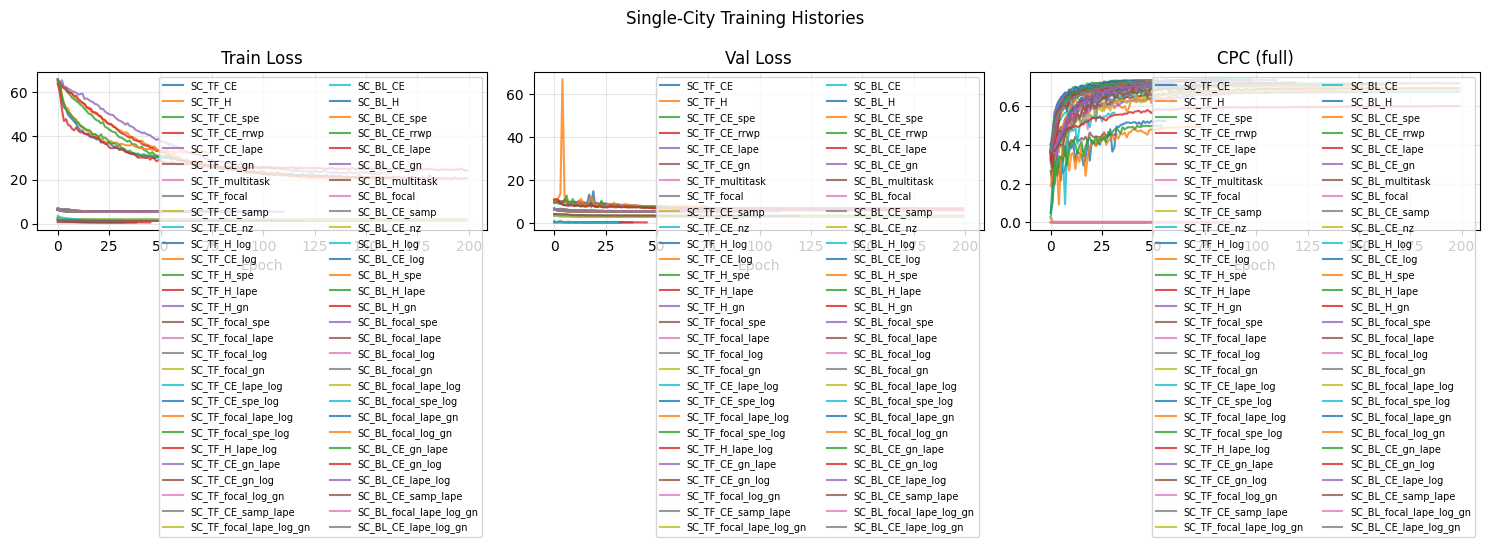

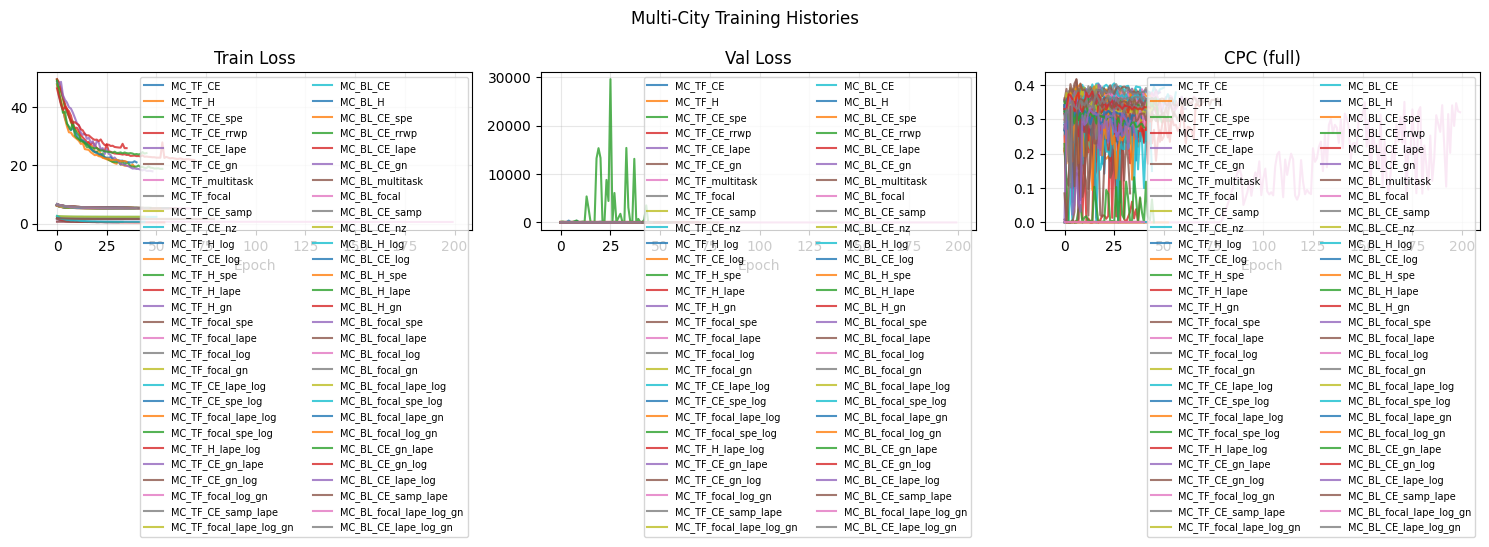

In [8]:
# Training curves
def plot_histories(results, title):
    if not results:
        return
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title)
    for rid, r in results.items():
        h = r.get('history', {})
        if not h:
            continue
        axes[0].plot(h.get('train_loss', []), label=rid, alpha=0.8)
        axes[1].plot(h.get('val_loss', []), label=rid, alpha=0.8)
        axes[2].plot(h.get('val_cpc_full', []), label=rid, alpha=0.8)
    axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch')
    axes[1].set_title('Val Loss');   axes[1].set_xlabel('Epoch')
    axes[2].set_title('CPC (full)'); axes[2].set_xlabel('Epoch')
    for ax in axes:
        ax.legend(fontsize=7, ncol=2)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_histories(sc_results, "Single-City Training Histories")
plot_histories(mc_results, "Multi-City Training Histories")
